In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [21]:
df=pd.read_csv("drug200.csv")

In [22]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [24]:
df=pd.get_dummies(df,columns=["Sex","BP","Cholesterol"],drop_first=True)

In [25]:
df.tail()

,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
195,56,11.567,drugC,False,True,False,False
196,16,12.006,drugC,True,True,False,False
197,52,9.894,drugX,True,False,True,False
198,23,14.020,drugX,True,False,True,True
199,40,11.349,drugX,False,True,False,True


In [26]:
le=LabelEncoder()
df["Drug"]=le.fit_transform(df["Drug"])

In [27]:
X=df.drop("Drug",axis=1)
y=df["Drug"]

In [28]:
ss=StandardScaler()
X=ss.fit_transform(X)

In [29]:
X

array([[-1.29159102,  1.28652212, -1.040833  , -0.68599434, -0.64686916,
        -0.97043679],
       [ 0.16269866, -0.4151454 ,  0.96076892,  1.45773797, -0.64686916,
        -0.97043679],
       [ 0.16269866, -0.82855818,  0.96076892,  1.45773797, -0.64686916,
        -0.97043679],
       ...,
       [ 0.46567567, -0.85908883,  0.96076892, -0.68599434,  1.54590766,
        -0.97043679],
       [-1.29159102, -0.28650033,  0.96076892, -0.68599434,  1.54590766,
         1.03046381],
       [-0.26146916, -0.6571702 , -1.040833  ,  1.45773797, -0.64686916,
         1.03046381]])

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
KNN=KNeighborsClassifier()
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [32]:
y_pred=KNN.predict(X_test)

In [35]:
Acc=accuracy_score(y_test,y_pred)
print("Accuracy : ",Acc)

Accuracy :  0.9


In [42]:
print("Classification Report")
cr=classification_report(y_test,y_pred)
print(cr)

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      0.80      0.89         5
           4       0.85      1.00      0.92        11

    accuracy                           0.90        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.91      0.90      0.90        40



In [44]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[12  1  0  0  2]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 1  0  0  4  0]
 [ 0  0  0  0 11]]


# VIZUALIZATION

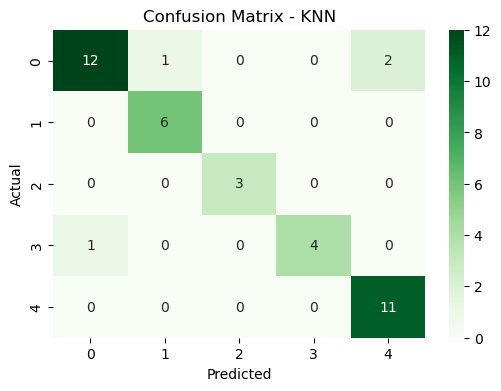

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()